# Codecademy
# Build a python web apps with Django

## HTML file vs DOM

HTML, JavaScript and CSS work together to style a web page with the template of a HTML syntax

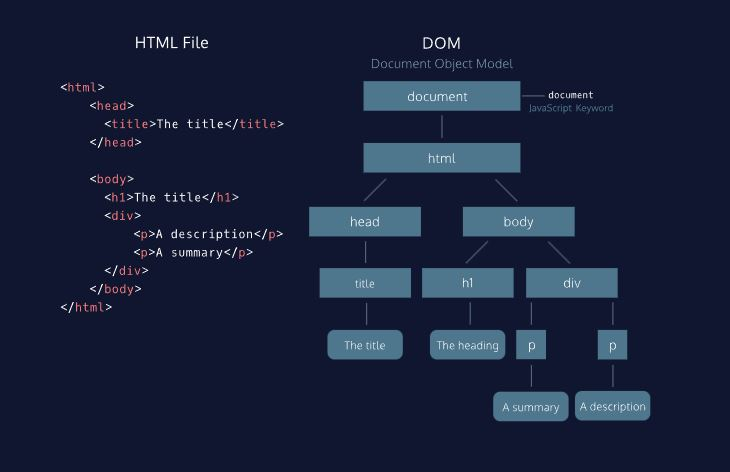

## Storing Data

You’ve probably heard that data is a big deal. By some measures, 90% of the world’s data has been generated in just the past two years. From a stored credit card number on an e-commerce site to the timestamp when you pause a video on a streaming platform, modern web applications collect and use large amounts of data. For that data to be useful, it must be organized and stored somewhere.

The back-ends of modern web applications include one or more databases. Databases are systems used to store and organize information so that it can be retrieved and updated efficiently. There are many types of databases, but they are commonly grouped into two broad categories: relational databases and non-relational databases (also known as NoSQL databases).

Relational databases organize data into tables made up of rows and columns. Each table typically represents a type of data, such as users, products, or orders. SQL (Structured Query Language) is commonly used to access and modify data stored in relational databases. Popular relational databases include MySQL and PostgreSQL.

Non-relational databases store data using other structures, such as key-value pairs, documents, or tree-like structures. These databases are often used when applications need flexible data formats or very large-scale data storage. Popular NoSQL databases include MongoDB and Redis.

In addition to storing the data, the 
back-end
Preview: Docs Loading link description
 must also include code that can read, create, update, and delete that data when requests are made by users or applications.

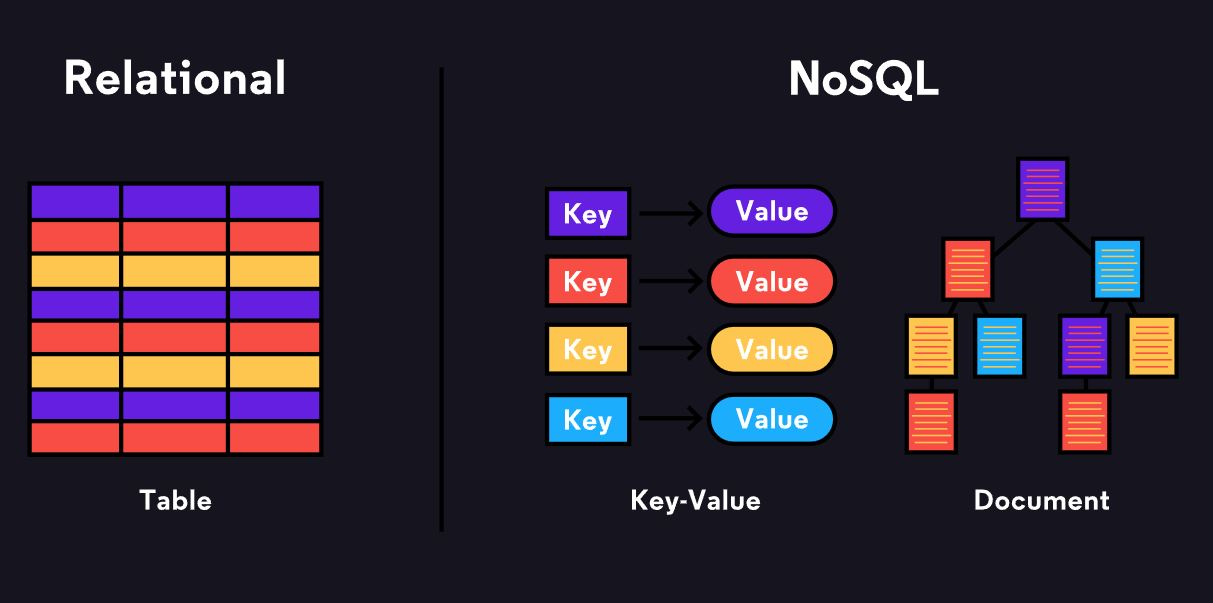

## What is an API?

When a user navigates to a specific item for sale on an e-commerce site, the price listed for that item is stored in a 
database
Preview: Docs Loading link description
. When they purchase it, the database must be updated to reflect the correct inventory. Much of what the 
back-end
Preview: Docs The back-end serves data to the front-end from sources like a database.
 does involves reading, creating, updating, or deleting data stored in a database.

To provide consistent ways for applications to interact with this data, a back-end often exposes a web API. 
API
Preview: Docs Loading link description
 stands for Application Programming Interface. In web development, a web API is a set of rules that allows applications to communicate with a 
server
Preview: Docs Loading link description
 and interact with its data, usually through an 
HTTP
Preview: Docs Loading link description
 request–response cycle.

Instead of simply requesting a webpage, these requests tell the server what action should be performed on the data. For example, an API request might create new data, retrieve existing data, update data, or delete data. The server processes the request, interacts with the database if needed, and then returns a response.

Let’s revisit the example of making an online purchase. When a user submits an order, the browser loads an order confirmation page. At the same time, the 
front-end
Preview: Docs Loading link description
 sends a request to the web API to record the order details and update the product inventory in the database.

Some web APIs are public, meaning other developers can use them to access certain features or data. For example, Instagram provides APIs that developers can use to interact with parts of the Instagram platform. Other APIs are internal, meaning they are only used by the application itself to allow different parts of the system to communicate.

## Different back-end stacks

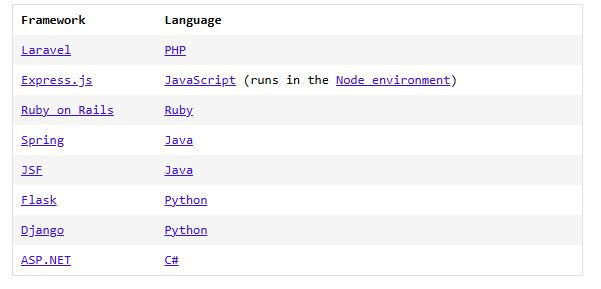

- The front-end of a website or application consists of the HTML, CSS, JavaScript, and static assets sent to a client, like a web browser.
- A web server is a process running on a computer somewhere that listens for incoming requests for information over the Internet and sends back responses.
- Storing, accessing, and manipulating data is a large part of a web application’s back-end.
- Data is stored in databases, which can be relational databases or NoSQL databases.
- The server-side of a web application, sometimes called the application server, handles important tasks such as authorization and authentication.
- The back-end of a web application often has a web API which is a way of interacting with an application’s data through HTTP requests and responses.
- Together, the technologies used to build the front-end and back-end of a web application are known as the stack, and many different languages and frameworks can be used to build a robust back-end.

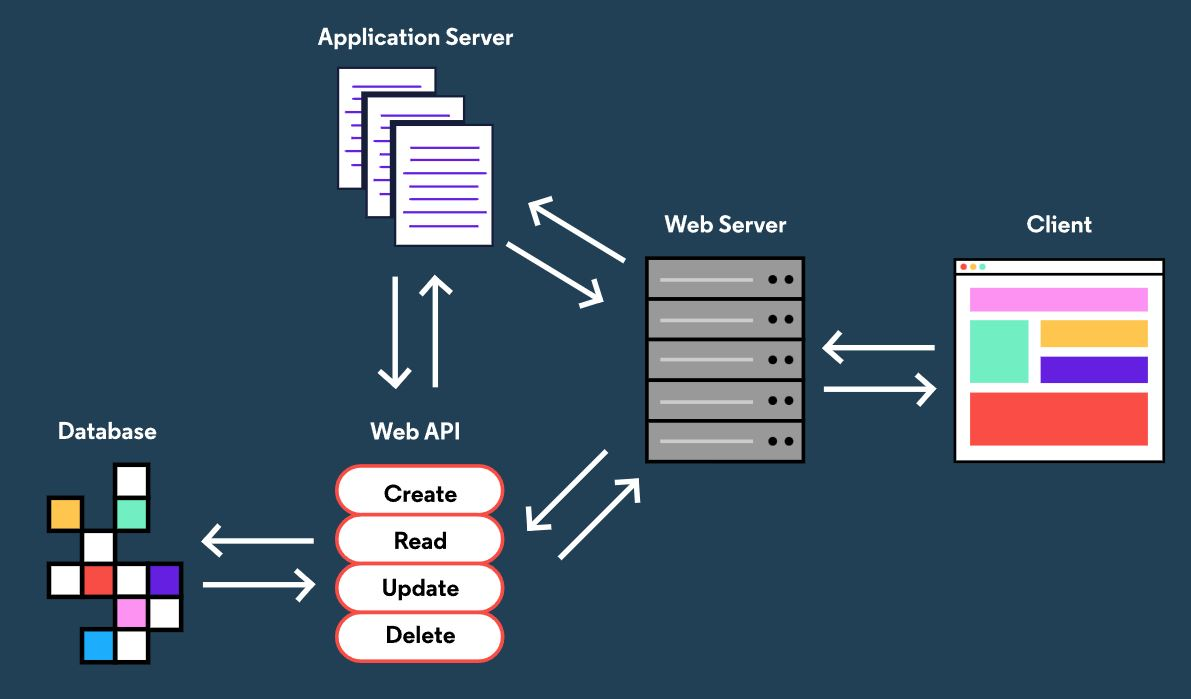

# Start a Django project





django-admin startproject projectname
#Para iniciar un proyecto en django

python3 manage.py runserver 0.0.0.0:4001 
#Para iniciar el servidor (La ip y el numero de puerto pueden cambiar)

python3 manage.py migrate 
#Para migrar todos los cambios no aplicados de la base de datos a la version actual

python3 manage.py startapp myapp
#Para iniciar un directorio nuevo para una django app

## views.py

```python
from django.shortcuts import render
# Import HttpResponse here
from django.http import HttpResponse

# Create your views here.
def home(request):
  return HttpResponse("Welcome to the Vet's office!")

The resulting templates folder structure will look like this:


myapp/
└── templates/
    └── myapp/
      └── mytemplate.html

## Creating a Django template

To place content generated from Django inside the HTML file, we need to turn our static HTML file into a template.

In the context of a web framework, templates are pages created with special markup that allows for backend data and commands to modify the contents of a page. Django employs a special syntax called Django Templating Language to distinguish itself from HTML, CSS, and JavaScript. That syntax in many template languages uses curly braces, sometimes referred to as handlebars, as a placeholder for data that is passed by Django.

In HTML, we use curly braces like this:

```html
<h1>Hello, {{name}}</h1>

When we call the view to render the template, we can use something called a context to tell Django what to replace in the template. The relationships in the context are referred to as a name/value pair. By default, a context is an empty dictionary. Our context for name will look like this inside the view function:

````python
context = {"name": "Junior"}


We then pass the context as an argument in the render function. The full view.py will look like this:

````python
from django.http import HttpResponse
from django.template import loader
def home(request):
  context = {"name": "Junior"}
  template = loader.get_template("app/home.html")
  return HttpResponse(template.render(context))


This would return a webpage that says “Hello, Junior” inside an <h1> tag.

It’s quite common in Django to load templates, fill their context, and return an HttpResponse object with their rendered template. Django provides a shortcut for this pattern called the render() function! The render() function will do the work of loading the template and provide the contexts when they are passed as arguments.

Our example above can be rewritten with the shortcut function like this:

````python
from django.shortcuts import render

def home(request):
  context = {"name": "Junior"}
  return render(request, "app/home.html", context)


Note that we no longer need to import loader and HttpResponse when we use the render() function. The render() function takes the request object as its first argument, a template name as its second argument, and a dictionary as an optional third argument that passes the context variables to the template.

## Wiring up a View

An app’s URLconf is located in a file named urls.py inside the app’s directory. At the top of the urls.py we import the path object from django.urls and we import the view functions from views.py and add routes that direct to each of our view functions.

The urls.py will look like this:

````python
from django.urls import path
from . import views

urlpatterns = [
  path('', views.home),
  path('profile/', views.profile, name="profile")  
]


After the import statements is a list of patterns called urlpatterns, which contain the routes to each view function. Each route is provided as a path() object that has three arguments: the URL route as a 
string, the name of the function of the view, and an optional name used to refer to the view.


With the above example, when we navigate to the URL without any additional route, '', the home() view function will be called. Going to the URL ending with /profile will call the profile() view function.